<a href="https://colab.research.google.com/github/jellybbie/study/blob/project1/Colab_%EC%8B%9C%EC%9E%91%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 특성2

## Load Data and Generate Heatmap

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Excel file into a pandas DataFrame
file_path = '/content/screening(2025)-5.xlsx'
df_full = pd.read_excel(file_path)

print(f'Successfully loaded data from: {file_path}')
print('\nFirst 5 rows of the DataFrame:')
display(df_full.head())


Successfully loaded data from: /content/screening(2025)-5.xlsx

First 5 rows of the DataFrame:


,Strain,IAA production,Cytokinin production,ACC deaminase activity,Phosphate solubilization,Nitrogen fixation
0,RMR-1,1.1787,0.1084,0.0488,0.4534,0.1425
1,RMR-2,1.0249,0.1206,0.0491,0.6858,0.1628
2,RMR-3,0.9659,0.1164,0.0486,0.7367,0.1588
3,RMR-4,1.2435,0.1166,0.0469,0.6707,0.1565
4,RMR-5,0.9413,0.1391,0.0857,0.7560,0.2239


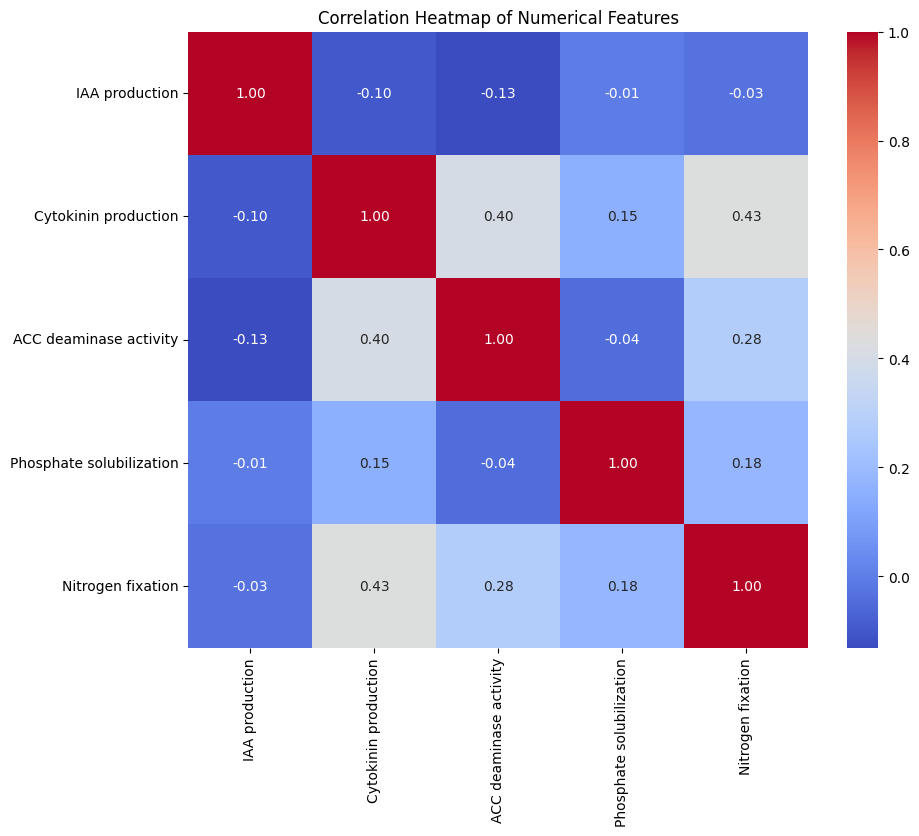

In [16]:
# Select only numerical columns for the heatmap
numerical_df = df_full.select_dtypes(include=['number'])

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


The heatmap above shows the correlation between the numerical features in your dataset. Stronger correlations (closer to 1 or -1) are indicated by more intense colors.

## Distribution of PGP Characteristics Across Strains

Let's visualize the distribution of each Plant Growth Promoting (PGP) characteristic across all strains using violin plots. This will help us understand the spread and central tendency of each trait.

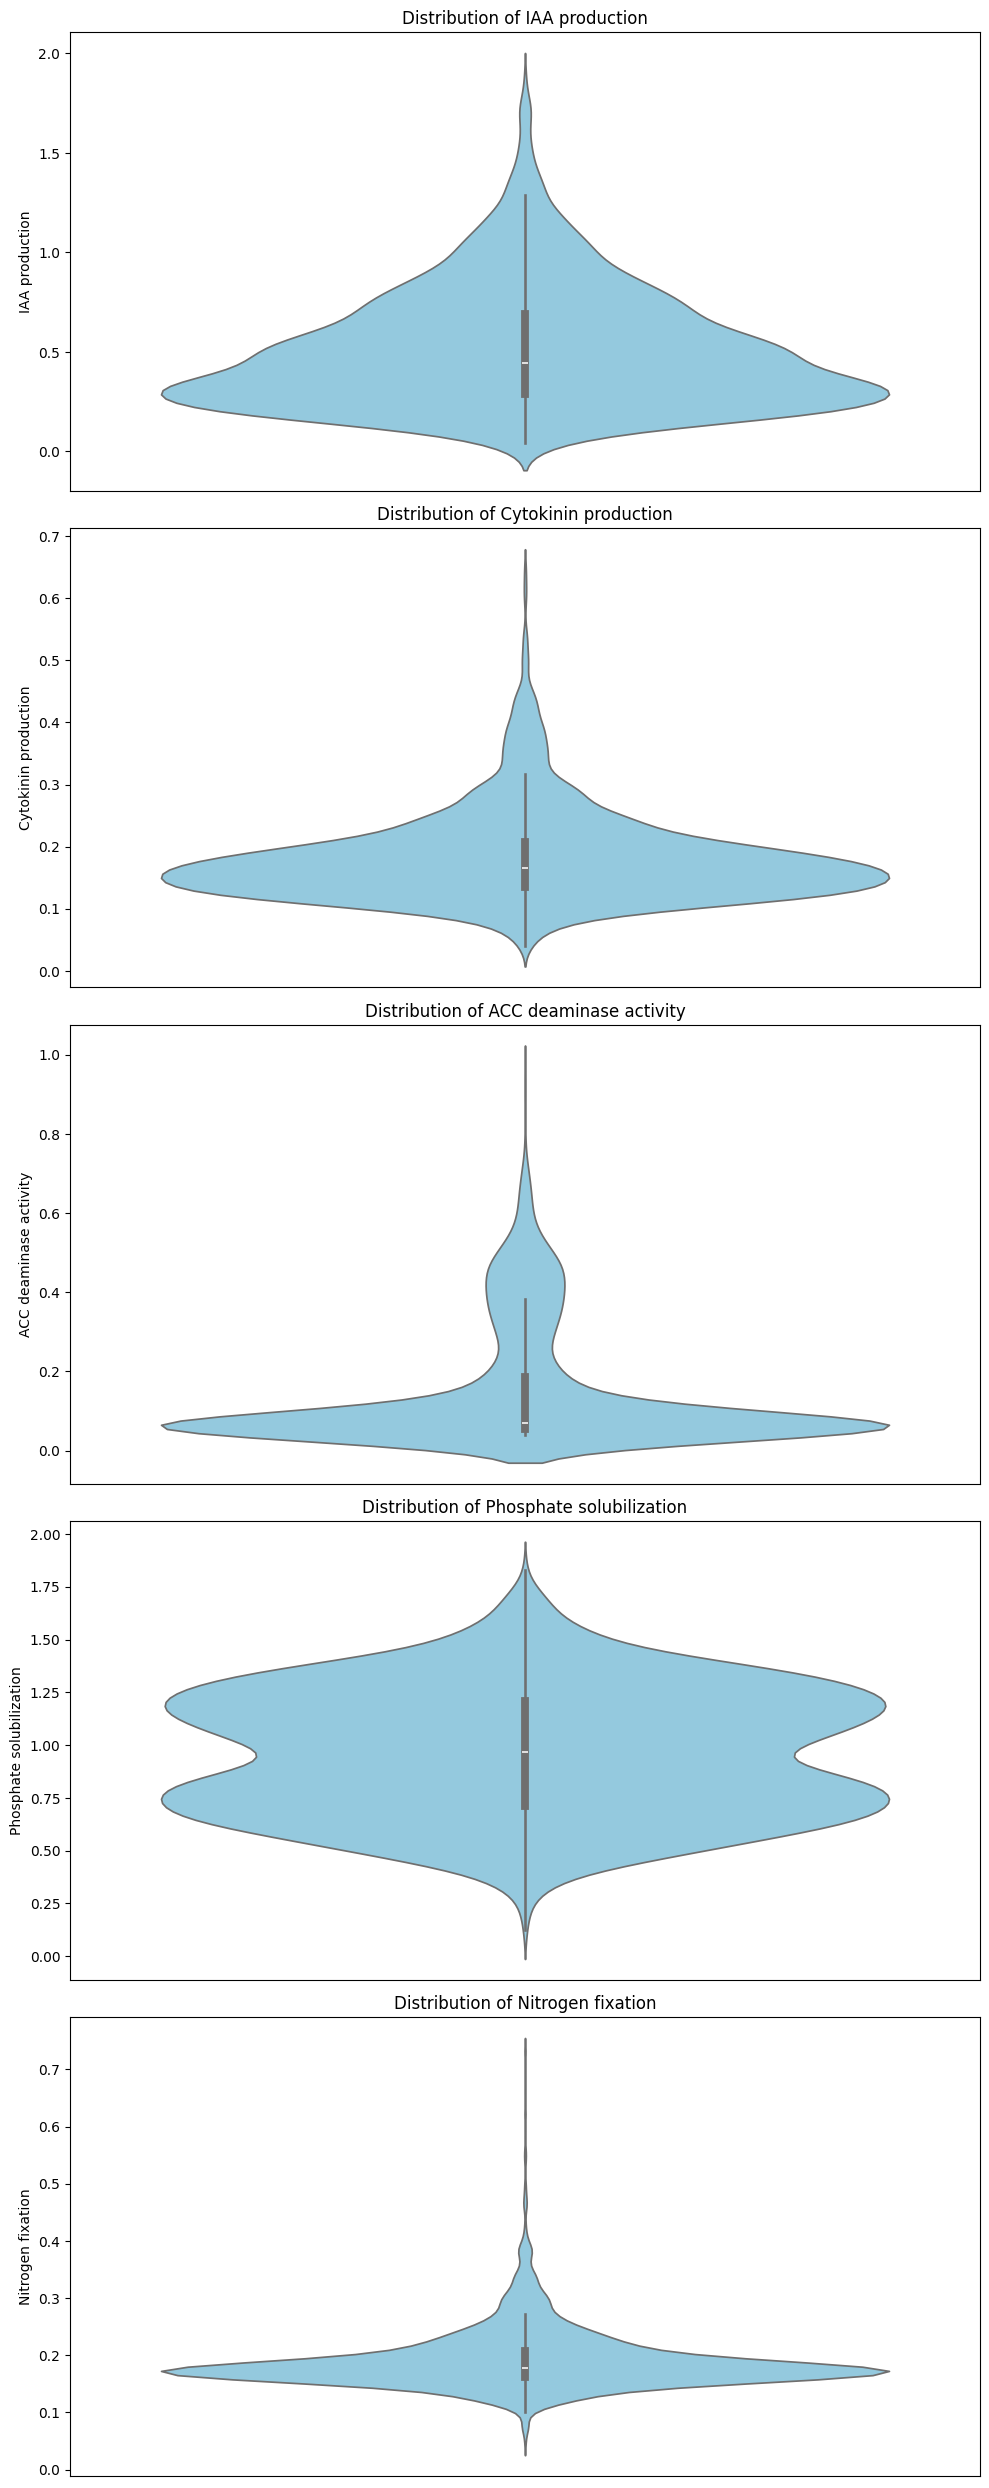

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the list of numerical characteristics (excluding 'Strain' if it were numerical)
pgp_characteristics = numerical_df.columns.tolist()

# Set up the figure and axes for the subplots
num_characteristics = len(pgp_characteristics)
fig, axes = plt.subplots(nrows=num_characteristics, ncols=1, figsize=(10, 5 * num_characteristics))

# Flatten axes array if there's only one subplot
if num_characteristics == 1:
    axes = [axes]

# Create a violin plot for each characteristic
for i, characteristic in enumerate(pgp_characteristics):
    sns.violinplot(y=df_full[characteristic], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {characteristic}')
    axes[i].set_ylabel(characteristic)
    axes[i].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False) # Remove x-axis ticks and labels

plt.tight_layout()
plt.show()


## Strain-wise PGP Characteristics Heatmap

To see how much each individual strain expresses each characteristic, we can generate a heatmap. This visualization will display the raw values of each PGP characteristic for every strain, allowing for easy comparison across both strains and characteristics.

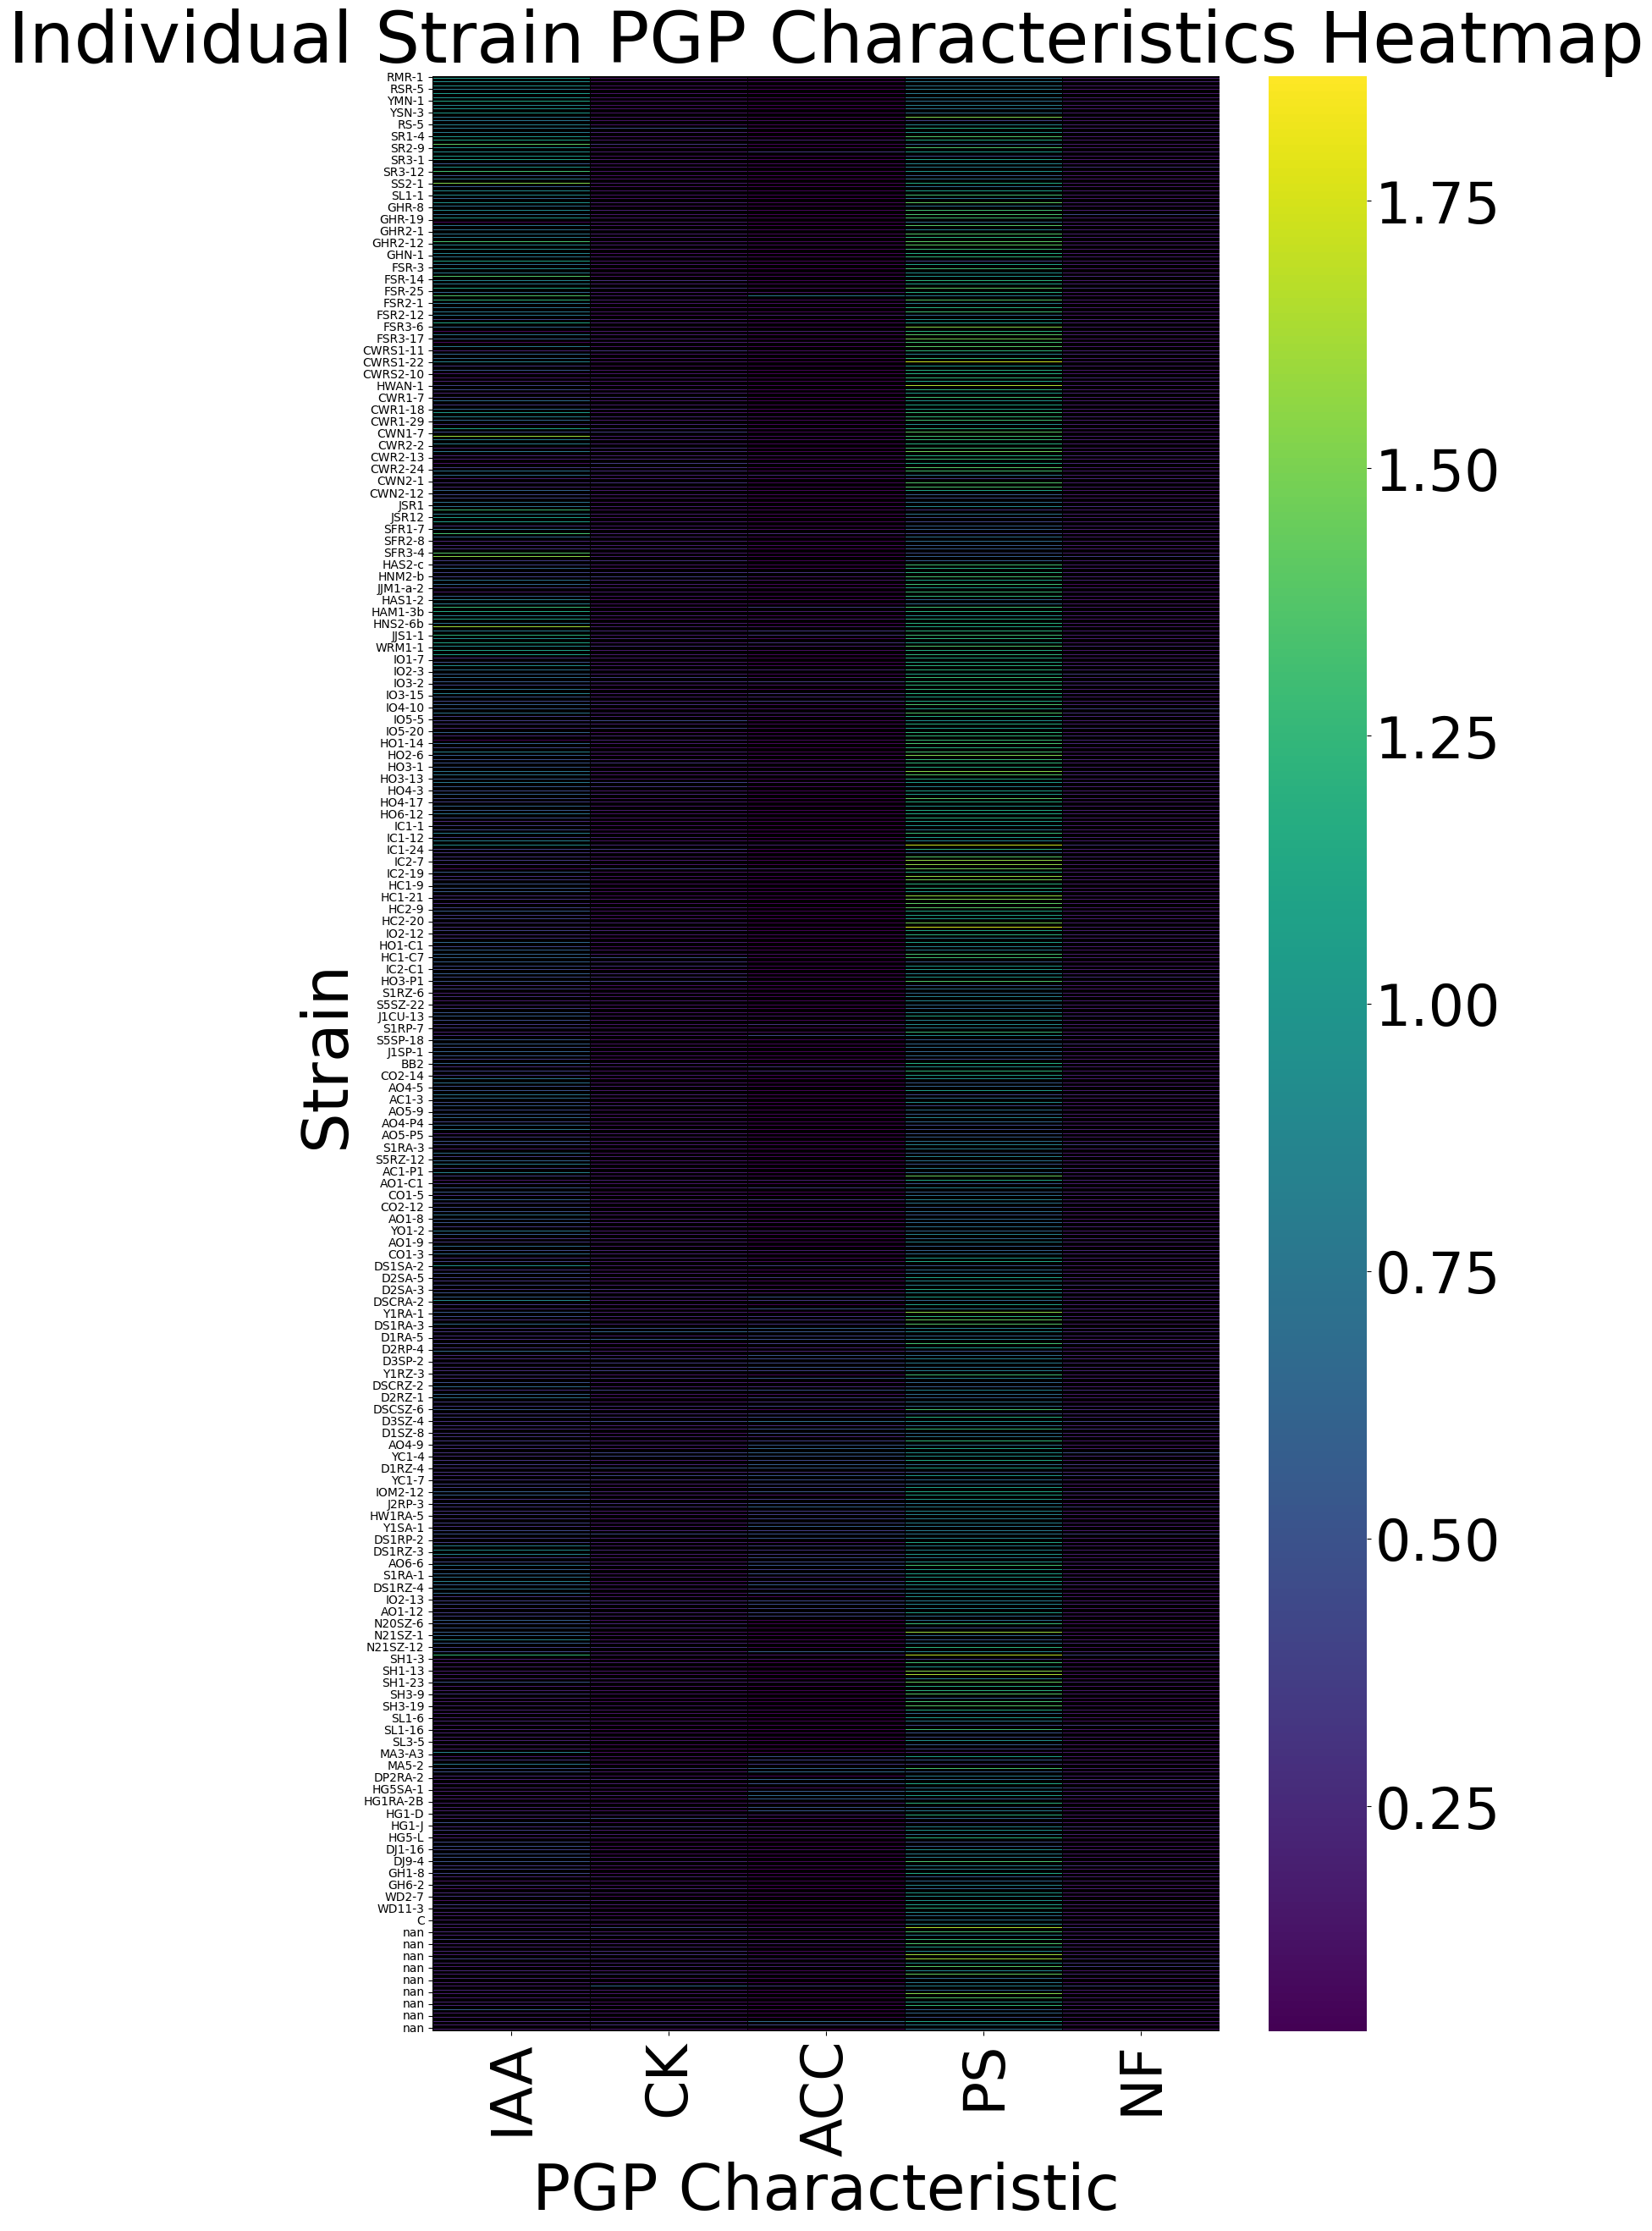

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data for the heatmap: set 'Strain' as index
# and select only the numerical PGP characteristics
heatmap_data = df_full.set_index('Strain')[pgp_characteristics]

plt.figure(figsize=(15, 30)) # Adjust figure size for better readability, especially with many strains
ax = sns.heatmap(heatmap_data, cmap='viridis', annot=False, fmt='.2f', linewidths=.5, linecolor='black')

# Adjust colorbar labelsize after creation
cb = ax.collections[0].colorbar # Get the colorbar object
cb.ax.tick_params(labelsize=48) # Set the labelsize for the colorbar ticks

plt.title('Individual Strain PGP Characteristics Heatmap', fontsize=60) # Increase title font size
plt.xlabel('PGP Characteristic', fontsize=54) # Increase x-label font size
plt.ylabel('Strain', fontsize=54) # Increase y-label font size

# Define abbreviations for characteristics
abbreviations = {
    'IAA production': 'IAA',
    'Cytokinin production': 'CK',
    'ACC deaminase activity': 'ACC',
    'Phosphate solubilization': 'PS',
    'Nitrogen fixation': 'NF'
}

# Get current x-axis labels and replace with abbreviations
current_xticklabels = [label.get_text() for label in ax.get_xticklabels()]
abbreviated_xticklabels = [abbreviations.get(label, label) for label in current_xticklabels]
ax.set_xticklabels(abbreviated_xticklabels, rotation=90, fontsize=48) # Set new labels with increased font size

plt.yticks(rotation=0, fontsize=10) # Ensure strain names are readable and adjust size

plt.show()

The heatmap above shows each strain's specific values for each PGP characteristic. Darker colors (depending on the colormap) generally indicate higher values for a given characteristic, while lighter colors indicate lower values. This allows for a direct comparison of the PGP potential of each strain across all tested traits.